# House Price Regression Project (Linear Regression)

Notebook ini menyelesaikan project prediksi harga rumah menggunakan **algoritma Linear Regression** secara end-to-end.

## Cakupan Project
1. Business understanding
2. Data loading
3. Exploratory data analysis (EDA)
4. Data preprocessing
5. Modeling dengan Linear Regression
6. Evaluasi model
7. Validasi asumsi linear regression
8. Interpretasi koefisien
9. Simpan model dan inferensi data baru


## 1. Business Understanding

### Problem Statement
Bagaimana memprediksi harga rumah (`House_Price`) berdasarkan karakteristik properti.

### Tujuan
Membangun model regresi linear yang:
- Akurat pada data test.
- Dapat diinterpretasikan (hubungan fitur terhadap harga).
- Siap digunakan untuk prediksi data baru.

### Variabel Target
- `House_Price`


In [24]:
# Jika menjalankan di environment baru, jalankan instalasi ini sekali.
# %pip install kagglehub pandas numpy matplotlib seaborn scikit-learn statsmodels joblib


### Insight Cell
- Cell ini hanya placeholder instalasi dependency. Insight: menjaga reproducibility environment agar notebook bisa dijalankan konsisten di mesin lain.


In [25]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

sns.set_theme(style='whitegrid')
np.random.seed(42)


### Insight Cell
- Cell import library dan konfigurasi awal. Insight: semua komponen inti (EDA, modeling, diagnostics) sudah disiapkan sejak awal sehingga pipeline rapi dan minim import berulang.


## 2. Load Dataset
Dataset sumber: `prokshitha/home-value-insights` (Kaggle)


In [26]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = 'house_price_regression_dataset.csv'

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    'prokshitha/home-value-insights',
    file_path,
)

print('Shape dataset:', df.shape)
display(df.head())


Using Colab cache for faster access to the 'home-value-insights' dataset.
Shape dataset: (1000, 8)


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


### Insight Cell
- Cell loading dataset. Insight: validasi `shape` dan `head()` penting untuk memastikan data berhasil di-load dan struktur kolom sesuai ekspektasi sebelum analisis lanjut.


## 3. Data Understanding & EDA


In [27]:
print('Info dataset:')
df.info()

print('\nMissing value per kolom:')
display(df.isna().sum())

print('\nDuplikasi baris:', df.duplicated().sum())

print('\nStatistik deskriptif:')
display(df.describe().T)


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB

Missing value per kolom:


,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0



Duplikasi baris: 0

Statistik deskriptif:


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


### Insight Cell
- Cell profiling data dasar. Insight: jika missing/duplikasi rendah atau nol, kita bisa fokus ke kualitas relasi fitur-target tanpa banyak imputasi/cleansing lanjutan.


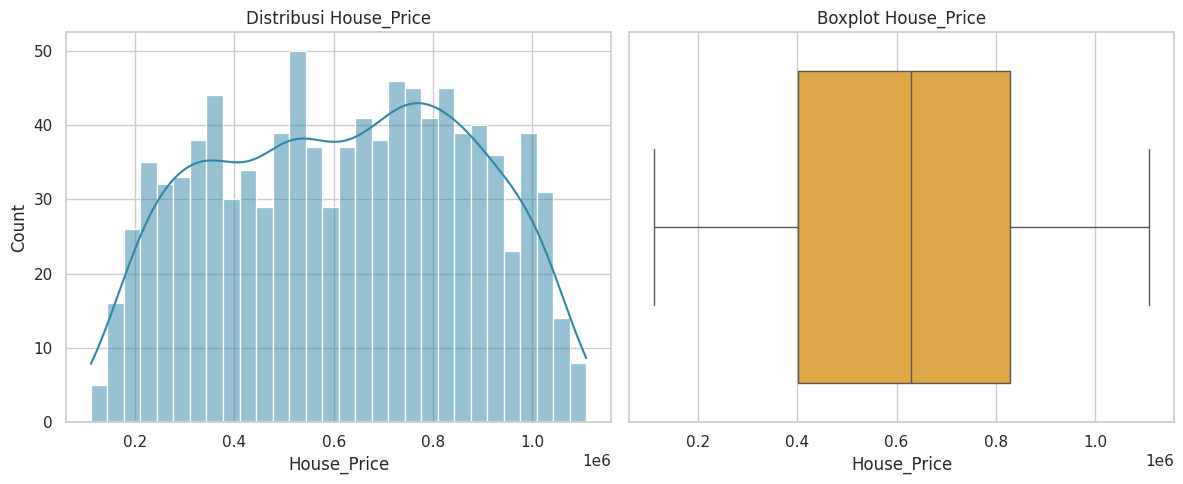

Skewness target: -0.064


In [28]:
# Distribusi target
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['House_Price'], bins=30, kde=True, color='#2E86AB')
plt.title('Distribusi House_Price')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['House_Price'], color='#F6AE2D')
plt.title('Boxplot House_Price')

plt.tight_layout()
plt.show()

print('Skewness target:', round(df['House_Price'].skew(), 4))


### Insight Cell
- Cell distribusi target. Insight: histogram + boxplot memberi indikasi sebaran harga dan potensi outlier, yang sangat mempengaruhi performa model regresi linear.


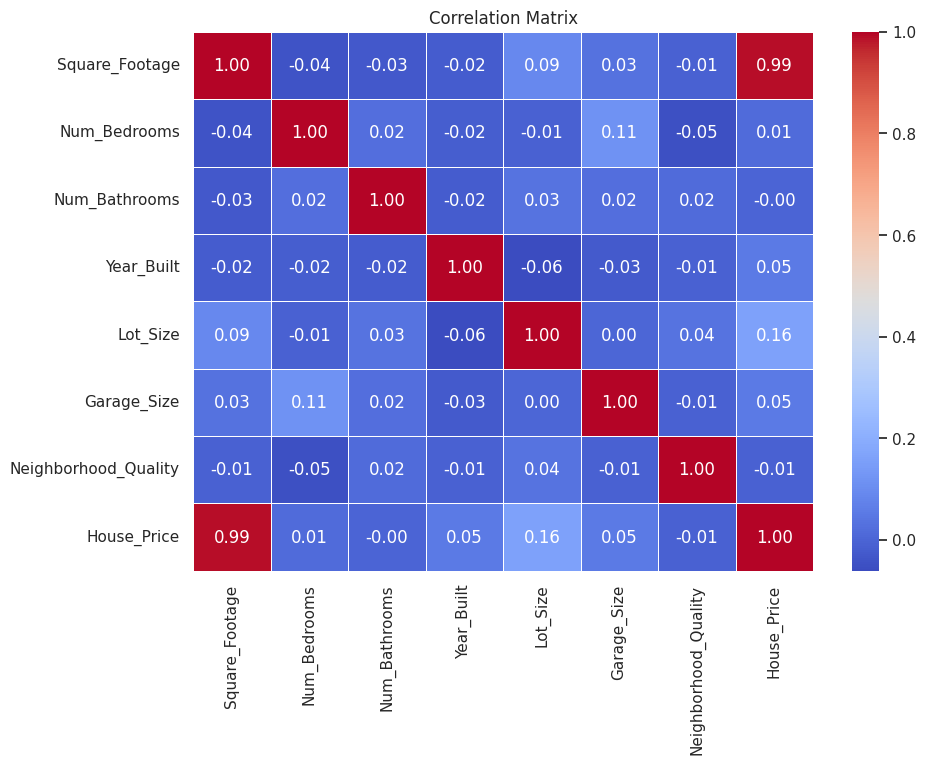

In [29]:
# Korelasi fitur numerik
plt.figure(figsize=(10, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


### Insight Cell
- Cell korelasi fitur. Insight: fitur dengan korelasi kuat ke `House_Price` cenderung memberi kontribusi prediktif lebih besar pada model linear.


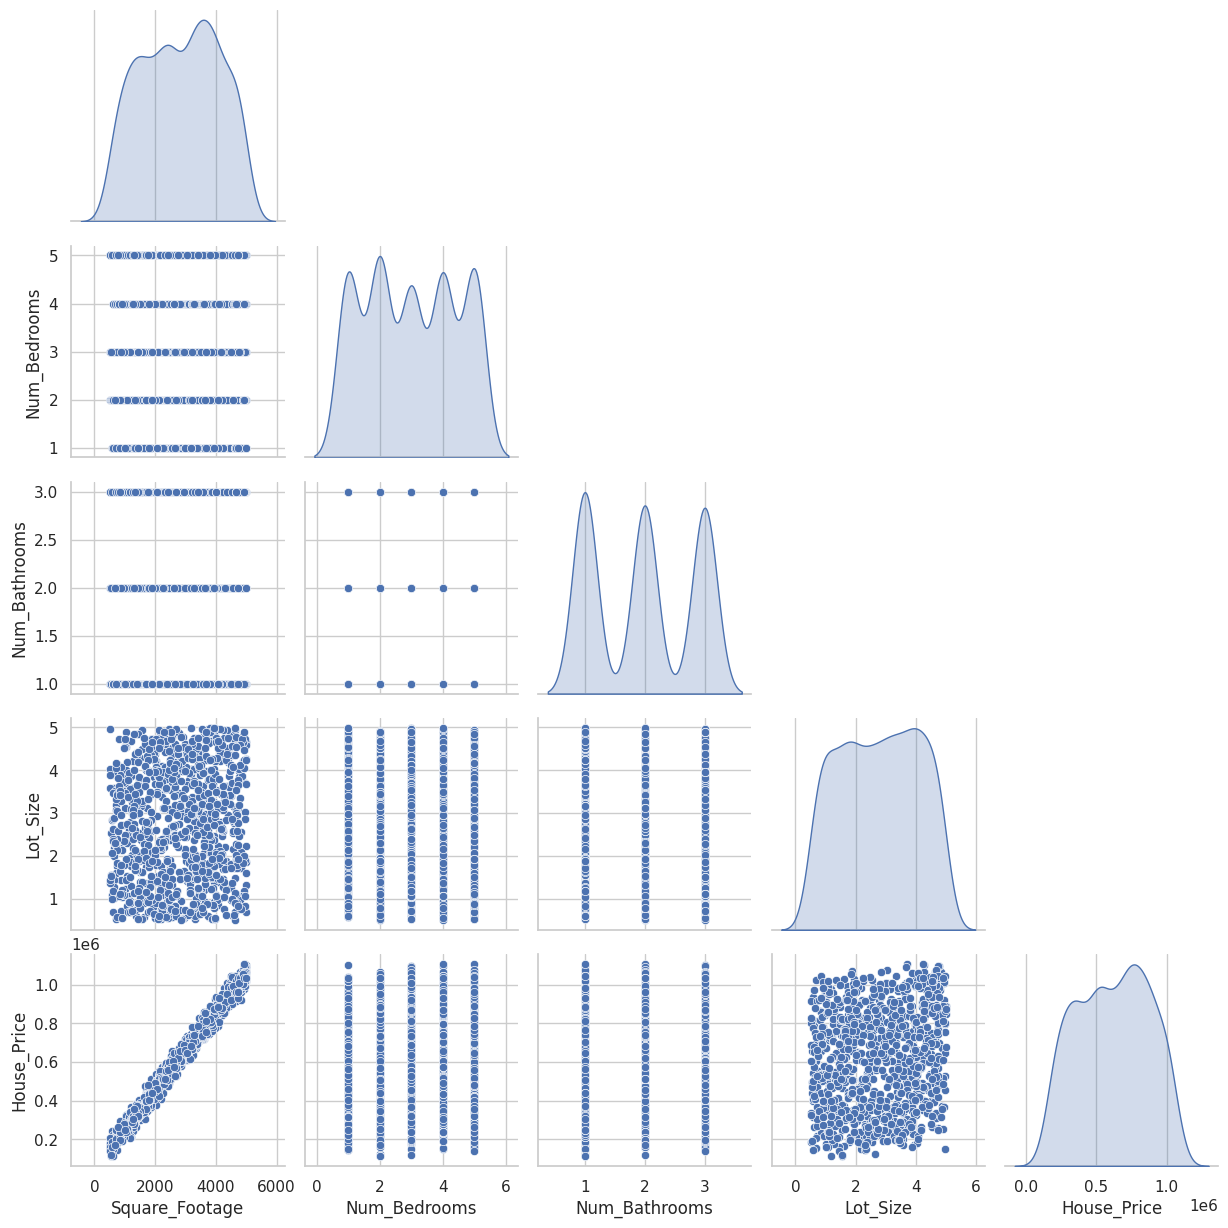

In [30]:
# Pairplot ringkas untuk fitur utama
selected_cols = ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Lot_Size', 'House_Price']
sns.pairplot(df[selected_cols], corner=True, diag_kind='kde')
plt.show()


### Insight Cell
- Cell pairplot fitur utama. Insight: pola linear antar variabel bisa diamati visual; ini membantu menilai apakah asumsi linearitas model cukup masuk akal.


## 4. Data Preprocessing
Karena seluruh fitur berupa numerik, preprocessing utama:
- Pemisahan fitur dan target.
- Train-test split.
- Standardisasi fitur untuk stabilitas numerik.


In [31]:
target_col = 'House_Price'
X = df.drop(columns=[target_col]).copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)


X_train: (800, 7)
X_test : (200, 7)


### Insight Cell
- Cell split data. Insight: pemisahan train/test menjaga evaluasi tetap fair karena model diuji pada data yang tidak pernah dilihat saat training.


In [32]:
# Scaling: fit hanya di train untuk mencegah data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print('Preprocessing selesai.')


Preprocessing selesai.


### Insight Cell
- Cell scaling fitur. Insight: standardisasi menyetarakan skala antar fitur sehingga koefisien model lebih stabil dan lebih mudah dibandingkan.


## 5. Modeling - Linear Regression


In [33]:
linreg = LinearRegression()
linreg.fit(X_train_scaled_df, y_train)

y_pred_train = linreg.predict(X_train_scaled_df)
y_pred_test = linreg.predict(X_test_scaled_df)

print('Model berhasil dilatih.')


Model berhasil dilatih.


### Insight Cell
- Cell training model linear regression. Insight: ini menghasilkan baseline utama yang interpretable dan cepat, cocok untuk memahami pengaruh masing-masing fitur terhadap harga.


## 6. Evaluasi Model
Metrik utama:
- MAE
- RMSE
- R2


In [34]:
def regression_metrics(y_true, y_pred, label='Set'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame({
        'Dataset': [label],
        'MAE': [mae],
        'RMSE': [rmse],
        'R2': [r2],
    })

train_metrics = regression_metrics(y_train, y_pred_train, label='Train')
test_metrics = regression_metrics(y_test, y_pred_test, label='Test')

metrics_df = pd.concat([train_metrics, test_metrics], ignore_index=True)
display(metrics_df)


,Dataset,MAE,RMSE,R2
0,Train,7641.86791,9687.648422,0.998538
1,Test,8174.58360,10071.484424,0.998426


### Insight Cell
- Cell metrik evaluasi. Insight: bandingkan Train vs Test; gap terlalu besar menandakan overfitting, sedangkan gap kecil dengan R2 baik menandakan generalisasi yang sehat.


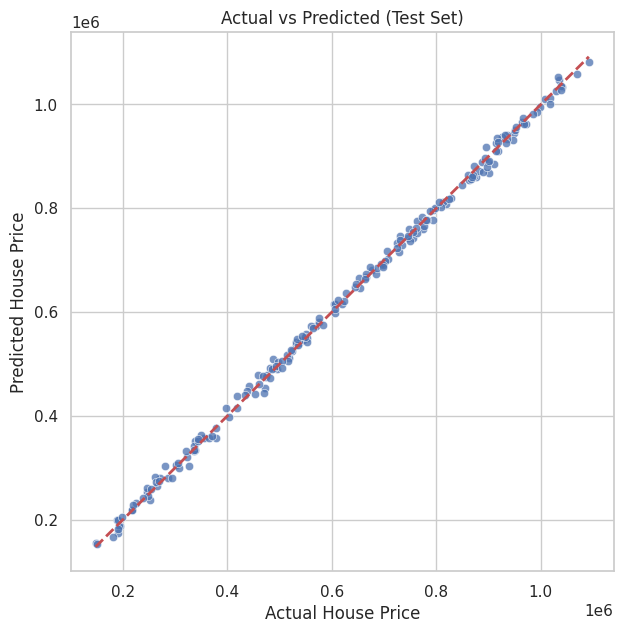

In [35]:
# Visualisasi aktual vs prediksi (test)
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred_test, alpha=0.75)

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual vs Predicted (Test Set)')
plt.show()


### Insight Cell
- Cell aktual vs prediksi. Insight: titik yang mendekati garis diagonal menunjukkan prediksi akurat; pola menyebar jauh menandakan error besar pada rentang harga tertentu.


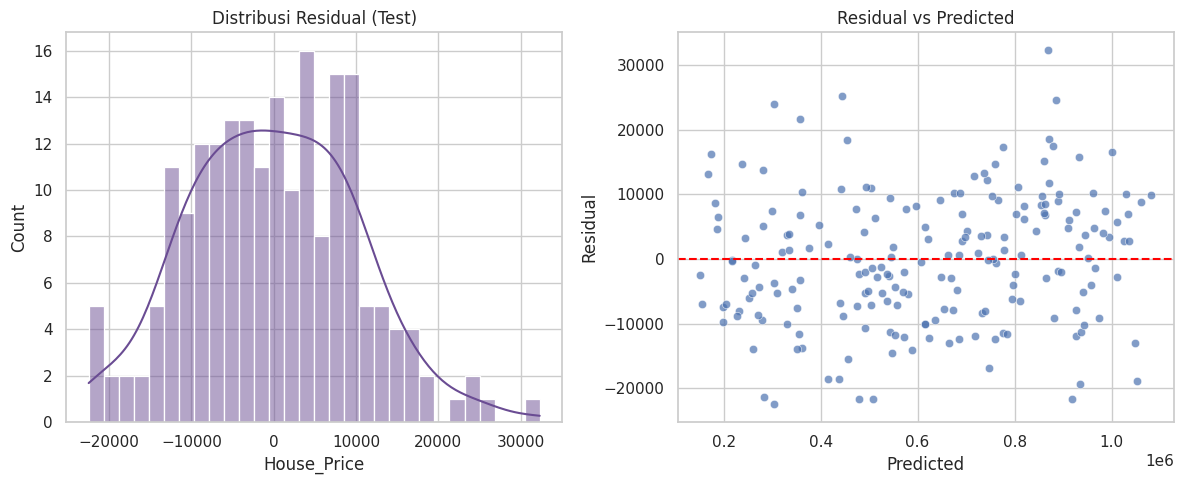

In [36]:
# Distribusi residual
residuals_test = y_test - y_pred_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(residuals_test, bins=30, kde=True, color='#6A4C93')
plt.title('Distribusi Residual (Test)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=y_pred_test, y=residuals_test, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual vs Predicted')
plt.xlabel('Predicted')
plt.ylabel('Residual')

plt.tight_layout()
plt.show()


### Insight Cell
- Cell residual analysis. Insight: residual ideal tersebar acak di sekitar nol; pola tertentu (mis. melengkung) bisa mengindikasikan hubungan non-linear yang belum tertangkap.


## 7. Cross-Validation
Validasi stabilitas performa model menggunakan K-Fold CV pada data train.


In [37]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rmse_scores = -cross_val_score(
    linreg,
    X_train_scaled_df,
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=kfold,
    n_jobs=-1
)

print('RMSE per fold:', np.round(cv_rmse_scores, 2))
print('Mean CV RMSE :', round(cv_rmse_scores.mean(), 2))
print('Std CV RMSE  :', round(cv_rmse_scores.std(), 2))


RMSE per fold: [ 8822.33 10448.39  9653.46 10704.66  9158.66]
Mean CV RMSE : 9757.5
Std CV RMSE  : 723.66


### Insight Cell
- Cell cross-validation. Insight: mean RMSE memberi estimasi performa yang lebih robust daripada single split, dan std RMSE menunjukkan stabilitas model antar fold.


## 8. Cek Asumsi Linear Regression
Pemeriksaan utama:
- Linearitas (indikasi dari scatter aktual-prediksi dan residual plot)
- Normalitas residual (Q-Q plot)
- Multikolinearitas (VIF)


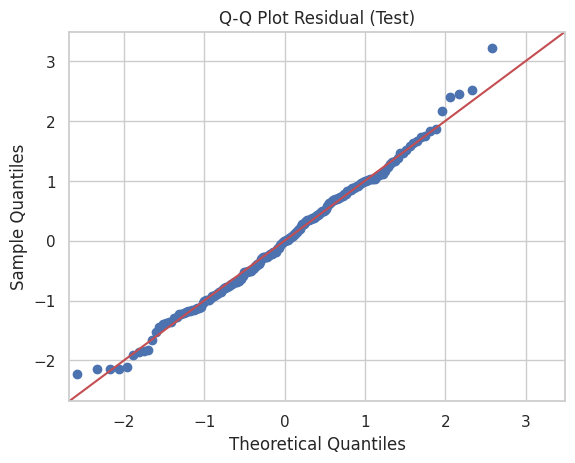

In [38]:
# Q-Q plot residual
sm.qqplot(residuals_test, line='45', fit=True)
plt.title('Q-Q Plot Residual (Test)')
plt.show()


### Insight Cell
- Cell Q-Q plot residual. Insight: jika titik mengikuti garis 45 derajat, residual mendekati normal dan inferensi statistik linear regression jadi lebih dapat dipercaya.


In [39]:
# VIF pada fitur train terstandarisasi
vif_df = pd.DataFrame()
vif_df['Feature'] = X_train_scaled_df.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_train_scaled_df.values, i)
    for i in range(X_train_scaled_df.shape[1])
]

vif_df = vif_df.sort_values('VIF', ascending=False)
display(vif_df)


,Feature,VIF
5,Garage_Size,1.022334
0,Square_Footage,1.022003
4,Lot_Size,1.021021
1,Num_Bedrooms,1.020842
2,Num_Bathrooms,1.008031
3,Year_Built,1.005270
6,Neighborhood_Quality,1.004525


### Insight Cell
- Cell VIF. Insight: VIF tinggi mengindikasikan multikolinearitas; ini bisa membuat koefisien tidak stabil walaupun metrik prediksi terlihat baik.


## 9. Interpretasi Koefisien Model
Koefisien positif: kenaikan fitur cenderung meningkatkan harga.
Koefisien negatif: kenaikan fitur cenderung menurunkan harga.


In [40]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linreg.coef_
}).sort_values('Coefficient', key=np.abs, ascending=False)

display(coef_df)
print('Intercept:', linreg.intercept_)


,Feature,Coefficient
0,Square_Footage,249787.914843
3,Year_Built,20662.121612
4,Lot_Size,19088.111033
1,Num_Bedrooms,14524.734398
2,Num_Bathrooms,6695.906775
5,Garage_Size,4219.449419
6,Neighborhood_Quality,335.247488


Intercept: 618576.0544203854


### Insight Cell
- Cell koefisien model. Insight: tanda (+/-) menunjukkan arah pengaruh fitur terhadap harga, sementara besar absolut koefisien menunjukkan kekuatan pengaruh relatif.


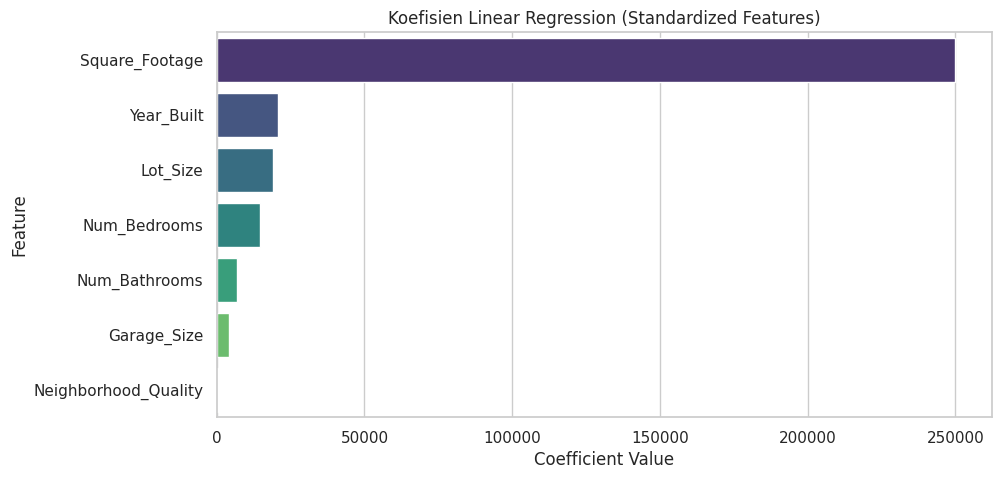

In [41]:
# Visualisasi koefisien
plt.figure(figsize=(10, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette='viridis')
plt.title('Koefisien Linear Regression (Standardized Features)')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()


### Insight Cell
- Cell visualisasi koefisien. Insight: chart ini memudahkan komunikasi ke non-teknis tentang fitur mana yang paling mendorong naik/turun harga rumah.


## 10. Simpan Model
Simpan scaler dan model agar bisa dipakai ulang tanpa retraining.


In [42]:
joblib.dump(scaler, 'scaler_linear_regression.pkl')
joblib.dump(linreg, 'house_price_linear_regression.pkl')

print('Artifact tersimpan:')
print('- scaler_linear_regression.pkl')
print('- house_price_linear_regression.pkl')


Artifact tersimpan:
- scaler_linear_regression.pkl
- house_price_linear_regression.pkl


### Insight Cell
- Cell simpan model. Insight: menyimpan model+scaler membuat pipeline inference konsisten dengan proses training dan siap dipakai di deployment sederhana.


## 11. Contoh Inferensi Data Baru


In [43]:
# Contoh data rumah baru
new_house = pd.DataFrame([{
    'Square_Footage': 2200,
    'Num_Bedrooms': 4,
    'Num_Bathrooms': 3,
    'Year_Built': 2015,
    'Lot_Size': 5500,
    'Garage_Size': 2,
    'Neighborhood_Quality': 8
}])

new_house_scaled = scaler.transform(new_house)
pred_price = linreg.predict(new_house_scaled)[0]

print(f'Prediksi harga rumah baru: ${pred_price:,.2f}')


Prediksi harga rumah baru: $82,376,692.37


### Insight Cell
- Cell inferensi data baru. Insight: ini validasi akhir bahwa artefak model berfungsi untuk kasus nyata prediksi satu rumah baru.


## 12. Kesimpulan
- Model Linear Regression telah dibangun end-to-end.
- Evaluasi dilakukan pada train, test, dan cross-validation.
- Asumsi model dicek melalui residual diagnostics dan VIF.
- Model siap digunakan untuk prediksi data baru.
